# L-Maze: Monte Carlo Control With ES

## Setup

In [24]:
# uncomment if needed
# %pip install "gym-classics2 @ git+https://github.com/mhahsler/gym-classics2.git"

In [25]:
import numpy as np
np.set_printoptions(precision=2)

SEED = 42
rng = np.random.default_rng(SEED)

In [26]:
import gymnasium as gym
import gym_classics2
gym_classics2.register()

/home/mhahsler/miniconda3/envs/reinforcement-learning/lib/python3.12/site-packages/gym_classics2/__init__.py:89: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "


## Define A L-Maze Grid World 

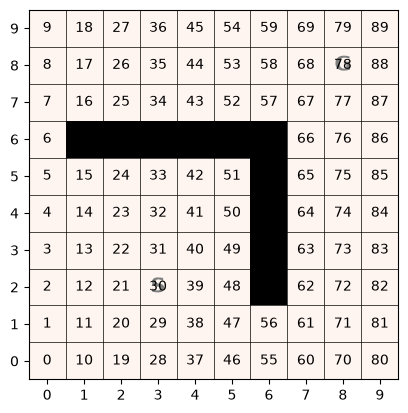

In [27]:
gym_env = gym.make('LMaze-v0', tabular = True)
env = gym_env.unwrapped
env.reset(seed=SEED)

env.image()

## Solve the Maze

In [28]:
from gym_classics2.algorithms.monte_carlo_methods import MC_control_ES

policy, Q, history = MC_control_ES(env, n=2000, discount=1, history=True, rng=rng)

MC Control (Incremental): 100%|██████████| 2000/2000 [00:00<00:00, 4282.50it/s]


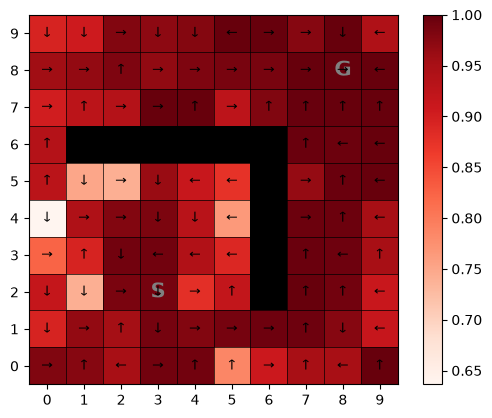

In [29]:
env.image(V = np.max(Q, axis = 1), policy = policy)

**Remember:** ES starts randomly, so the algorithm tries to find the best solution from any state. We have not run the algorithm for an infinite number of episodes, so the policy is not perfect.

## Learning Curve

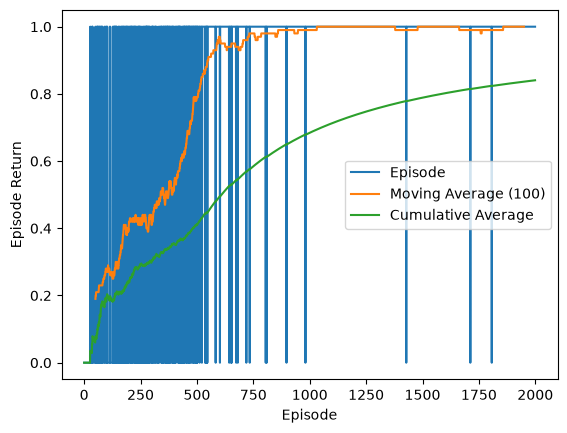

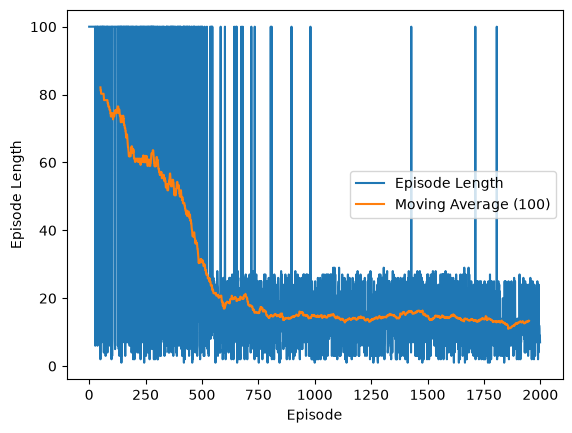

In [30]:
from gym_classics2.performance import plot_returns, plot_ep_lens
plot_returns(history["returns"])
plot_ep_lens([len(x) for x in history["episodes"]])

An early policy shows that there still are areas where the policy leads to a loop.

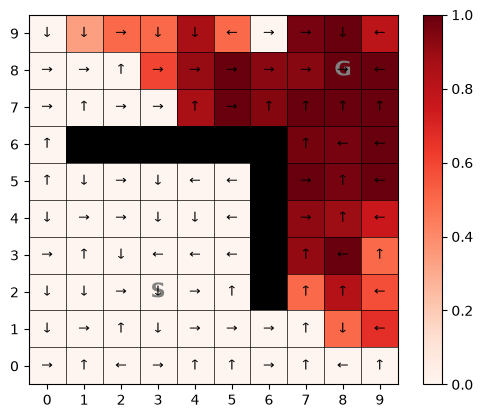

In [31]:
pol = history["policies"][250]
Q = history["Q_values"][250]

env.image(V = np.max(Q, axis = 1), policy = policy)



&copy; 2025 [Michael Hahsler](https://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)